# 🔍 Customer Behavior Analytics & Churn Prediction
### Teyzix Core Internship | Task DA-INT-1
**Author:** Muhammad Tayyab  
**Date:** June 11, 2026  
**Dataset:** Telco Customer Churn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📚 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Teyzix-Internship/Task-1/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🔎 3. Exploratory Data Analysis (EDA)

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'].value_counts().tail(10)

,count
TotalCharges,
6565.85,1
2117.2,1
203.95,1
6849.4,1
692.35,1
130.15,1
3211.9,1
7843.55,1
2196.3,1


In [ ]:
df[df['TotalCharges'].str.strip() == ''].shape

(11, 21)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

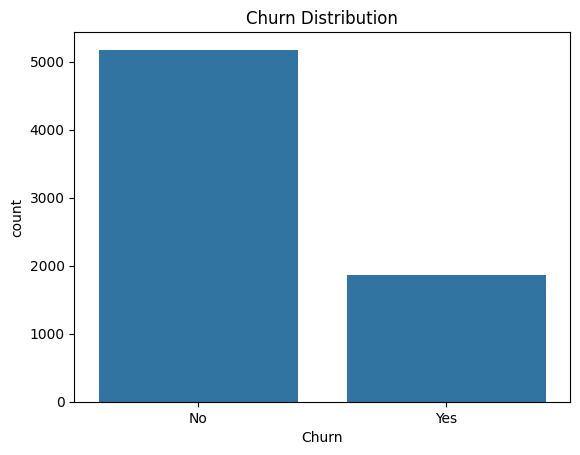

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

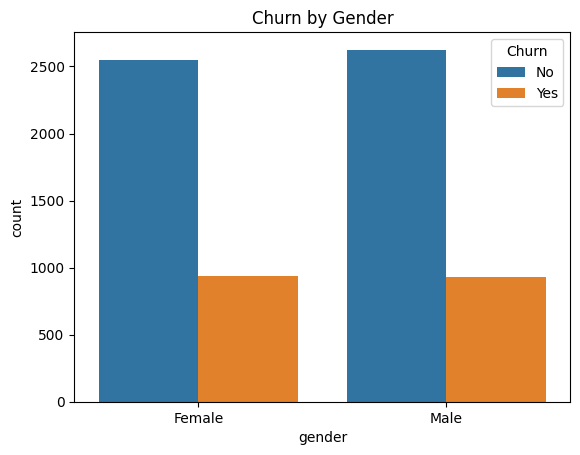

In [ ]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Churn by Gender')
plt.show()

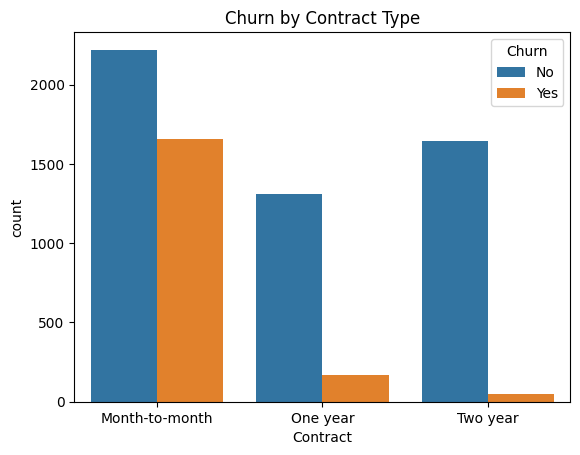

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

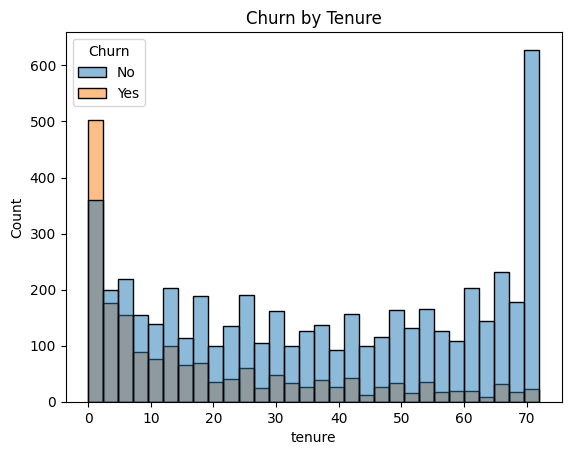

In [ ]:
sns.histplot(x='tenure', hue='Churn', data=df, bins=30)
plt.title('Churn by Tenure')
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

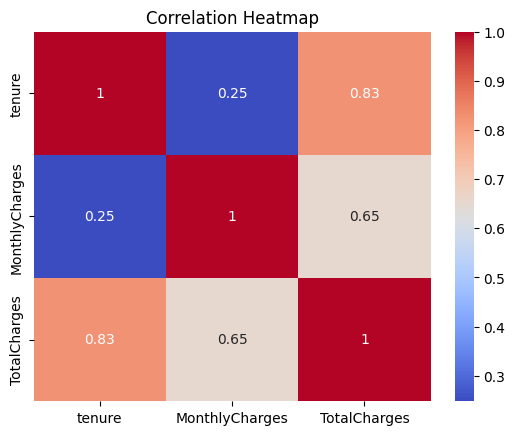

In [ ]:
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 🧹 4. Data Cleaning

In [ ]:
df['Churn']=df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.shape

(7043, 32)

In [ ]:
df.columns.tolist()

['customerID',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'gender_Male',
 'SeniorCitizen_1',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [ ]:
df.drop(columns=['customerID'], inplace=True)

In [ ]:
df.shape

(7043, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7032 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   gender_Male                            7043 non-null   bool   
 5   SeniorCitizen_1                        7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

In [ ]:
df = df.astype({col:int for col in df.select_dtypes(bool).columns})

In [ ]:
df

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,0,1,0,1,1,1,0,...,0,1,0,1,1,0,1,0,0,1
7039,72,103.20,7362.90,0,0,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,0
7040,11,29.60,346.45,0,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,4,74.40,306.60,1,1,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1


In [ ]:
df.dtypes

,0
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64
gender_Male,int64
SeniorCitizen_1,int64
Partner_Yes,int64
Dependents_Yes,int64
PhoneService_Yes,int64
MultipleLines_No phone service,int64


## ⚙️ 5. Feature Engineering

In [ ]:
def tenure_group(tenure):
    if tenure <= 12:
        return 'New'
    elif tenure <= 48:
        return 'Mid'
    else:
        return 'Loyal'

In [ ]:
df['tenure_group'] = df['tenure'].apply(tenure_group)
df['tenure_group'].value_counts()

,count
tenure_group,
Mid,2618
Loyal,2239
New,2186


In [ ]:
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure']
df['avg_monthly_spend'].head()

,avg_monthly_spend
0,29.850000
1,55.573529
2,54.075000
3,40.905556
4,75.825000


In [ ]:
df.columns.tolist()

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'gender_Male',
 'SeniorCitizen_1',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'tenure_group',
 'avg_monthly_spend']

In [ ]:
service_cols = ['PhoneService_Yes', 'MultipleLines_Yes',
                'OnlineSecurity_Yes', 'OnlineBackup_Yes',
                'DeviceProtection_Yes', 'TechSupport_Yes',
                'StreamingTV_Yes', 'StreamingMovies_Yes']

df['services_count'] = df[service_cols].sum(axis=1)
df['services_count'].value_counts().sort_index()

,count
services_count,
0,80
1,1701
2,1188
3,965
4,922
5,908
6,676
7,395
8,208


In [ ]:
df.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_monthly_spend,services_count
0,1,29.85,29.85,0,0,0,1,0,0,1,...,0,0,0,1,0,1,0,New,29.850000,1
1,34,56.95,1889.50,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,Mid,55.573529,3
2,2,53.85,108.15,1,1,0,0,0,1,0,...,0,0,0,1,0,0,1,New,54.075000,3
3,45,42.30,1840.75,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,Mid,40.905556,3
4,2,70.70,151.65,1,0,0,0,0,1,0,...,0,0,0,1,0,1,0,New,75.825000,1


In [ ]:
df['has_internet'] = 1 - df['InternetService_No']

In [ ]:
df['has_internet'].head()

,has_internet
0,1
1,1
2,1
3,1
4,1


In [ ]:
df['tenure_group'] = df['tenure_group'].map({
    'New': 0,
    'Mid': 1,
    'Loyal': 2
})
df['tenure_group'].value_counts()

,count
tenure_group,
1,2618
2,2239
0,2186


## 🤖 7. Machine Learning Models

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']
print(X.shape)
print(y.shape)

(7043, 34)
(7043,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(5634, 34)
(1409, 34)


In [ ]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0
TotalCharges,10
avg_monthly_spend,10


In [ ]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=15000, random_state=42,class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=15000, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = lr_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.82      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC Score: 0.7739798875857855


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.67      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

ROC-AUC Score: 0.686966265384496


## 👥 8. Customer Segmentation

In [ ]:
def segment_customer(row):
    if row['avg_monthly_spend'] > 65 and row['tenure'] > 48:
        return 'High Value'
    elif row['avg_monthly_spend'] > 35 and row['tenure'] > 12:
        return 'Medium Value'
    else:
        return 'Low Value'

df['customer_segment'] = df.apply(segment_customer, axis=1)
df['customer_segment'].value_counts()

,count
customer_segment,
Low Value,3291
Medium Value,2271
High Value,1481


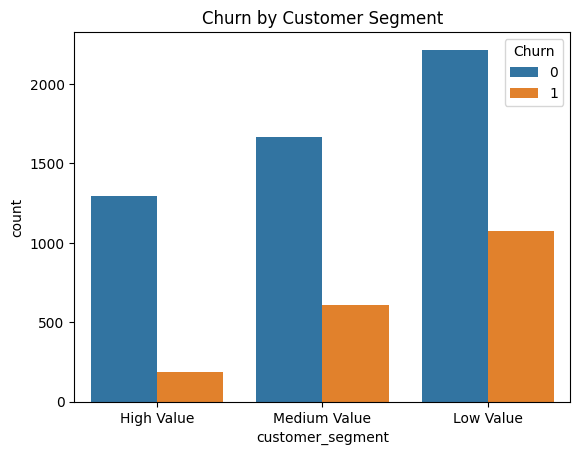

In [ ]:
sns.countplot(x='customer_segment', hue='Churn', data=df,
              order=['High Value', 'Medium Value', 'Low Value'])
plt.title('Churn by Customer Segment')
plt.show()

## 🎯 9. Churn Prediction System

In [ ]:
def predict_churn(customer_data):
    # Predict probability
    prob = lr_model.predict_proba(customer_data)[0][1]

    # Risk category
    if prob < 0.3:
        risk = 'Low Risk 🟢'
    elif prob < 0.6:
        risk = 'Medium Risk 🟡'
    else:
        risk = 'High Risk 🔴'

    return {
        'Churn Probability': f'{prob*100:.2f}%',
        'Risk Category': risk
    }

In [ ]:
# Pehla test customer
for i in range(15):
  test_customer = X_test[i:i+1]
  result = predict_churn(test_customer)
  print(result)

{'Churn Probability': '84.81%', 'Risk Category': 'High Risk 🔴'}
{'Churn Probability': '17.37%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '1.19%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '79.92%', 'Risk Category': 'High Risk 🔴'}
{'Churn Probability': '1.87%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '54.89%', 'Risk Category': 'Medium Risk 🟡'}
{'Churn Probability': '10.19%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '1.19%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '13.75%', 'Risk Category': 'Low Risk 🟢'}
{'Churn Probability': '40.13%', 'Risk Category': 'Medium Risk 🟡'}
{'Churn Probability': '39.38%', 'Risk Category': 'Medium Risk 🟡'}
{'Churn Probability': '61.85%', 'Risk Category': 'High Risk 🔴'}
{'Churn Probability': '39.15%', 'Risk Category': 'Medium Risk 🟡'}
{'Churn Probability': '73.79%', 'Risk Category': 'High Risk 🔴'}
{'Churn Probability': '23.95%', 'Risk Category': 'Low Risk 🟢'}


In [ ]:
print("Actual:", y_test.iloc[0:16])

Actual: 185     1
2715    0
3825    0
1807    1
132     0
1263    1
3732    0
1672    0
811     1
2526    1
2892    0
4129    0
2622    0
3801    1
4357    0
6179    1
Name: Churn, dtype: int64


## 💡 10. Business Insights Report

### 1. Top Churn Reasons
- **Month-to-month contract** customers churn most —
  no long-term commitment or binding
- **New customers (Low tenure)** churn in first 12 months —
  loyalty not yet developed
- **Low Value segment** has highest churn rate —
  new customers with low spending and no commitment
### 2. High Risk Customer Traits
- **Month-to-month contract** — no long term commitment
- **Low tenure (0-12 months)** — new customers, loyalty not developed
- **High Monthly Charges** — paying more but not satisfied with service
### 3. Revenue Impact
- Total Churned Customers: 1,869
- Average Monthly Charge: $64.76
- Monthly Revenue Loss: $121,039.60
- Annual Revenue Loss: $1,452,475.24

💡 Retaining even 50% churned customers could save
   $726,237 annually!
### 4. Recommendations
- **Convert Month-to-month to Long-term contracts** —
  offer discounts on yearly/2-year plans to reduce churn
  
- **New Customer Onboarding Program** —
  special offers and better support in first 12 months
  to build loyalty
  
- **VIP Treatment for High Value Customers** —
  priority support, exclusive discounts to retain
  high revenue customers

- **Target High Risk customers immediately** —
  use prediction system to identify and retain
  customers with 60%+ churn probability

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
0,61.265124
1,74.441332


In [ ]:
avg_revenue = df['MonthlyCharges'].mean()
churned = df['Churn'].sum()
monthly_loss = avg_revenue * churned
annual_loss = monthly_loss * 12

print(f"Churned Customers: {churned}")
print(f"Monthly Revenue Loss: ${monthly_loss:,.2f}")
print(f"Annual Revenue Loss: ${annual_loss:,.2f}")

Churned Customers: 1869
Monthly Revenue Loss: $121,039.60
Annual Revenue Loss: $1,452,475.24


## 📊 6. Data Visualization

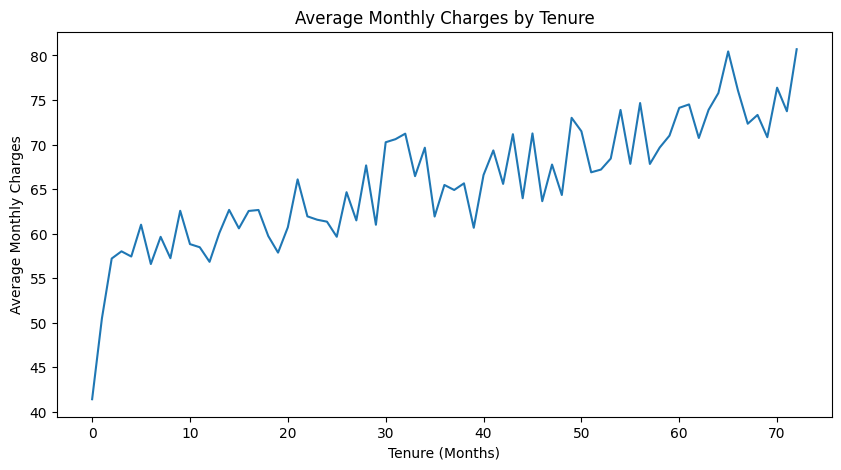

In [ ]:
plt.figure(figsize=(10,5))
df.groupby('tenure')['MonthlyCharges'].mean().plot()
plt.title('Average Monthly Charges by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Monthly Charges')
plt.show()

Business Insight:

Purane customers zyada services lete hain — isliye charges barhte hain — purane customers zyada valuable hain! 💸


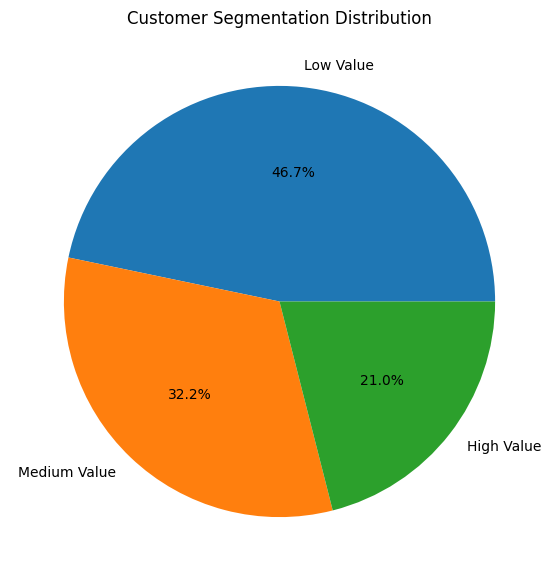

In [ ]:
plt.figure(figsize=(7,7))
df['customer_segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Segmentation Distribution')
plt.ylabel('')
plt.show()

Business Insight:

Sirf 21% High Value customers hain — but yeh sabse zyada revenue dete hain — inhe rokna #1 priority! 💸



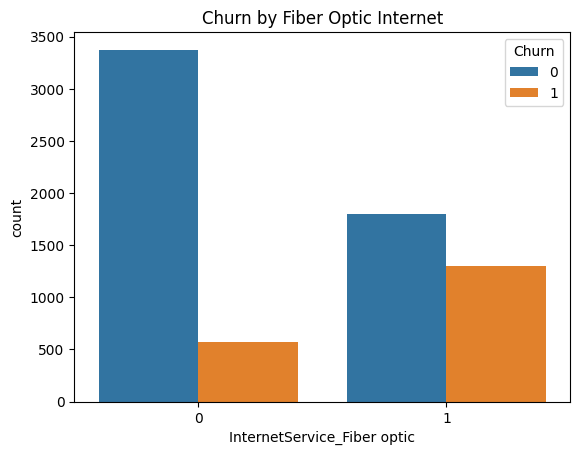

In [ ]:
sns.countplot(x='InternetService_Fiber optic', hue='Churn', data=df)
plt.title('Churn by Fiber Optic Internet')
plt.show()

Business Insight:

Fiber optic customers pe special dhyan do — yeh high paying hain but satisfaction kam hai! 💸

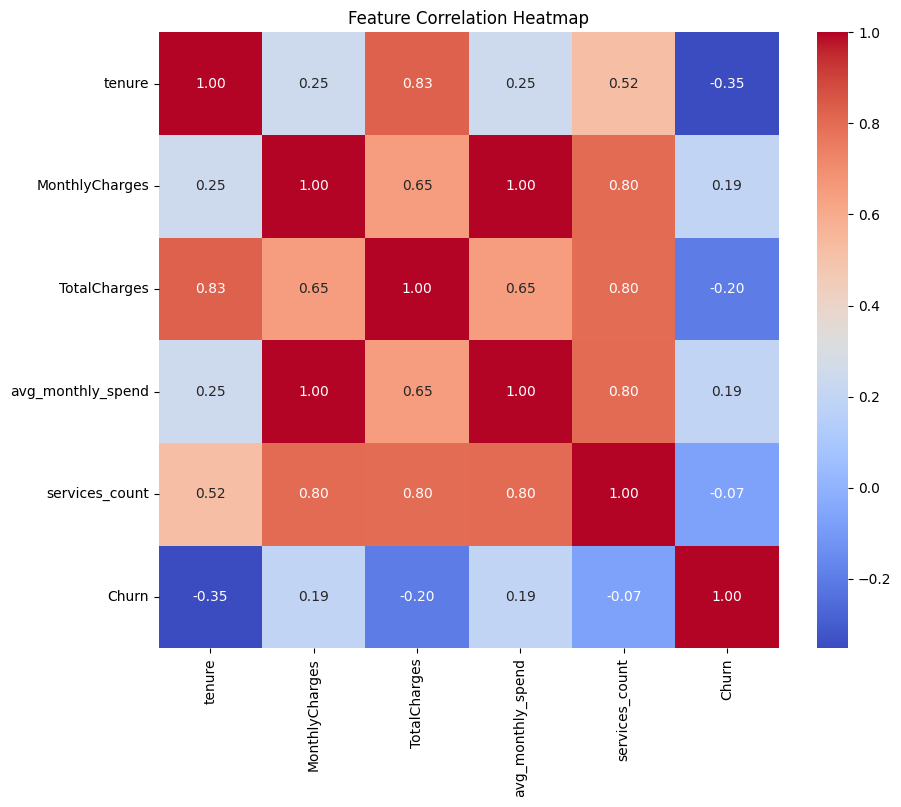

In [ ]:
new_num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'avg_monthly_spend', 'services_count', 'Churn']

plt.figure(figsize=(10,8))
sns.heatmap(df[new_num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

1. tenure → Churn = -0.35

Jitna purana customer — utna kam churn karega!

Business Action:

Naye customers ko jaldi loyal banao — first 12 mahine mein special offers do! 💡


2. MonthlyCharges → Churn = 0.19

Zyada pay karne wale thoda zyada churn karte hain!

Business Action:

High paying customers ko better service do — woh expect karte hain zyada! 💡

##SHAP

In [ ]:
!pip install shap -q

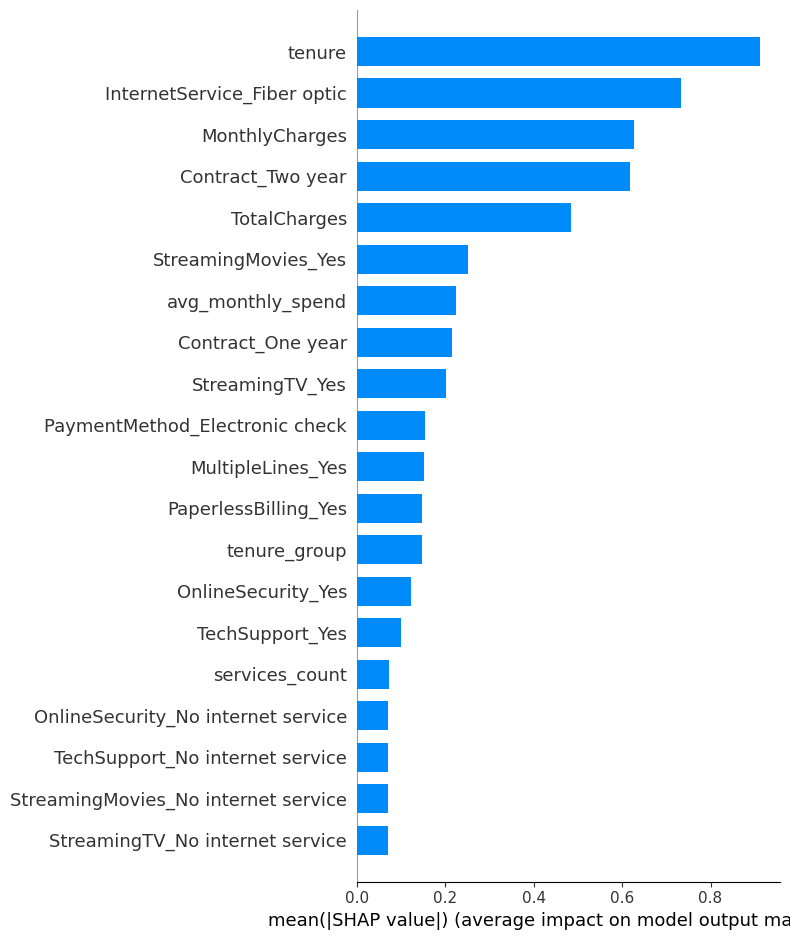

In [ ]:
import shap

feature_columns = [col for col in df.columns if col != 'Churn' and col != 'customer_segment']
# SHAP explainer banao
explainer = shap.LinearExplainer(lr_model, X_train)
shap_values = explainer.shap_values(X_test[:100])

# Summary plot
shap.summary_plot(shap_values, X_test[:100],
                  feature_names=feature_columns,
                  plot_type='bar')

In [ ]:
import joblib
joblib.dump(lr_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
print(X_train.columns.tolist() if hasattr(X_train, 'columns') else list(range(X_train.shape[1])))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [ ]:

print(feature_columns)
joblib.dump(feature_columns, 'feature_columns.pkl')

['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group', 'avg_monthly_spend', 'services_count', 'has_internet']


['feature_columns.pkl']

In [ ]:
joblib.dump(shap_values, 'shap_values.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']